In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [36]:
df = pd.read_csv("placement-dataset.csv")

In [37]:
df['cgpa'].fillna(df['cgpa'].mean(), inplace=True)
df['iq'].fillna(df['iq'].mean(), inplace=True)
print(df.head() )

          city  cgpa   iq  placement
0     New York   6.8  123          1
1  Los Angeles   5.9  106          0
2     New York   7.4  132          1
3  Los Angeles   5.8  142          0
4     New York   5.7  140          0


C:\Users\nalab\AppData\Local\Temp\ipykernel_14748\2949844602.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['cgpa'].fillna(df['cgpa'].mean(), inplace=True)
C:\Users\nalab\AppData\Local\Temp\ipykernel_14748\2949844602.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignme

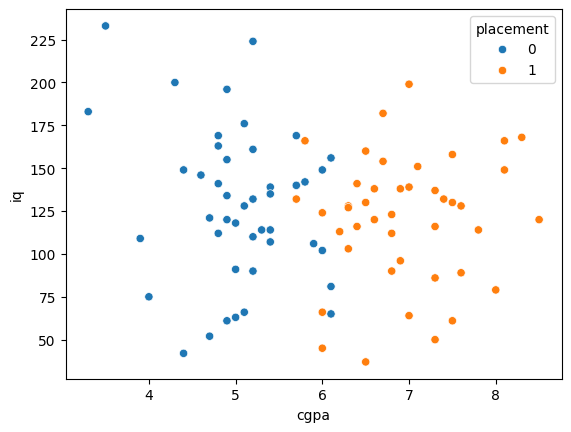

In [38]:
sns.scatterplot(x=df['cgpa'], y=df['iq'], hue=df['placement'])
plt.show()

In [39]:
X = df.iloc[:,1:3].copy()
X['cgpa'] = pd.to_numeric(X['cgpa'], errors='coerce')
X['iq'] = pd.to_numeric(X['iq'], errors='coerce')

y = df.iloc[:,-1].astype(int)

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
from sklearn.linear_model import Perceptron
model = Perceptron(max_iter=1000)

In [42]:
model.fit(X_scaled,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [43]:
print(model.coef_  )
print(model.intercept_  )

[[ 4.84071557 -0.45658772]]
[-1.]


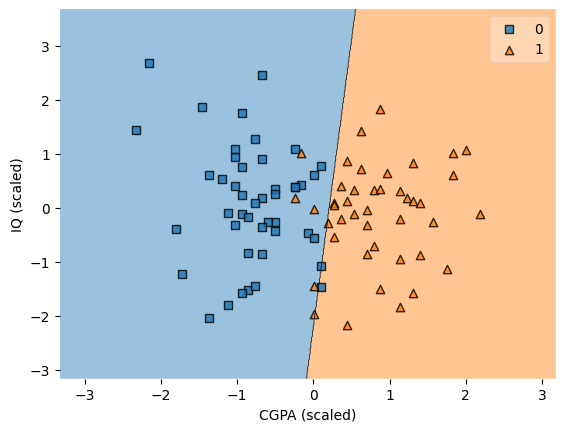

In [44]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_scaled, y.values, clf=model)
plt.xlabel('CGPA (scaled)')
plt.ylabel('IQ (scaled)')
plt.show()

In [46]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_scaled)
print(accuracy_score(y, y_pred))

0.9318181818181818


In [47]:
print("Training Accuracy:", model.score(X_scaled, y))


Training Accuracy: 0.9318181818181818
